In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
start = '2012-01-01'
end = '2022-12-21'
stock = 'GOOG'

data = yf.download(stock, start, end)

[*********************100%***********************]  1 of 1 completed


In [3]:
data.reset_index(inplace=True)

In [4]:
data

Price,Date,Close,High,Low,Open,Volume
Ticker,,GOOG,GOOG,GOOG,GOOG,GOOG
0,2012-01-03,16.438175,16.505864,16.116037,16.130119,147611217
1,2012-01-04,16.509071,16.557738,16.319840,16.428785,114989399
2,2012-01-05,16.280067,16.402599,16.211391,16.357144,131808205
3,2012-01-06,16.057983,16.304527,16.052300,16.283528,108119746
4,2012-01-09,15.377144,15.983377,15.346757,15.971023,233776981
...,...,...,...,...,...,...
2756,2022-12-14,94.533882,96.428333,93.175043,94.762013,26452900
2757,2022-12-15,90.457344,93.264301,89.693618,92.778293,28298800
2758,2022-12-16,90.120132,91.002885,89.277055,90.457360,48485500


In [5]:
ma_100_days = data.Close.rolling(100).mean()

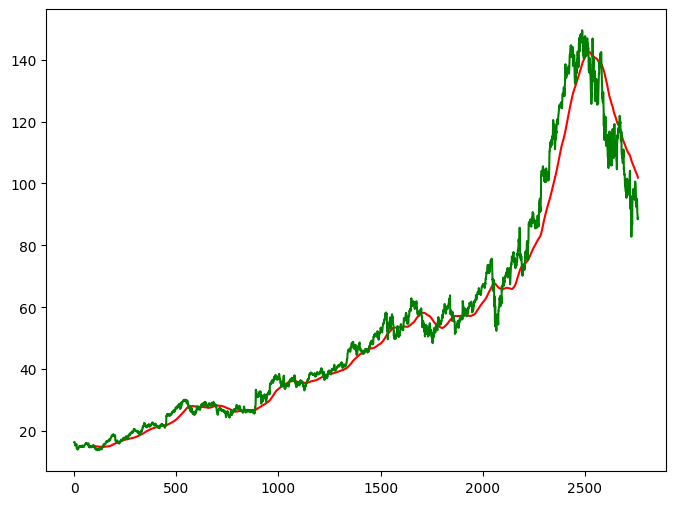

In [6]:
plt.figure(figsize=(8,6))
plt.plot(ma_100_days, 'r')
plt.plot(data.Close, 'g')
plt.show()

In [7]:
ma_200_days = data.Close.rolling(200).mean()

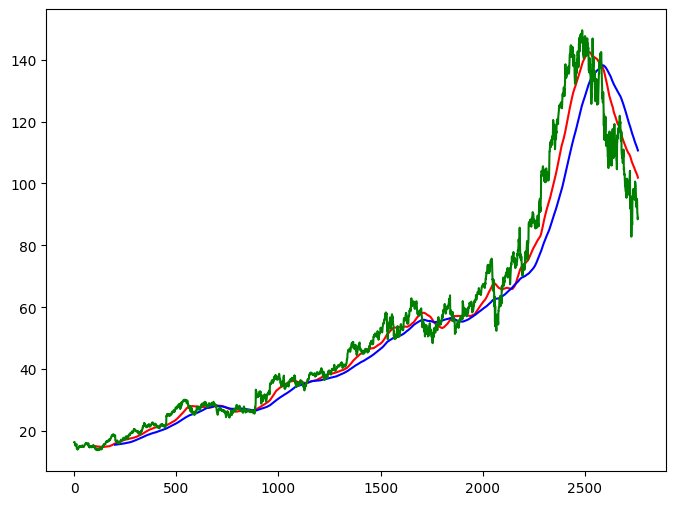

In [8]:
plt.figure(figsize=(8,6))
plt.plot(ma_100_days, 'r')
plt.plot(ma_200_days,'b')
plt.plot(data.Close,'g')
plt.show()

In [9]:
data.dropna(inplace=True)

data

Price,Date,Close,High,Low,Open,Volume
Ticker,,GOOG,GOOG,GOOG,GOOG,GOOG
0,2012-01-03,16.438175,16.505864,16.116037,16.130119,147611217
1,2012-01-04,16.509071,16.557738,16.319840,16.428785,114989399
2,2012-01-05,16.280067,16.402599,16.211391,16.357144,131808205
3,2012-01-06,16.057983,16.304527,16.052300,16.283528,108119746
4,2012-01-09,15.377144,15.983377,15.346757,15.971023,233776981
...,...,...,...,...,...,...
2756,2022-12-14,94.533882,96.428333,93.175043,94.762013,26452900
2757,2022-12-15,90.457344,93.264301,89.693618,92.778293,28298800
2758,2022-12-16,90.120132,91.002885,89.277055,90.457360,48485500


In [21]:
data_train = pd.DataFrame(data.Close[0: int(len(data)*0.80)])
data_test = pd.DataFrame(data.Close[int(len(data)*0.80): len(data)])
print(data_test.shape)
print(data_test.head())

(553, 1)
Ticker       GOOG
2208    77.818611
2209    77.944092
2210    77.765556
2211    77.321693
2212    78.010048


In [11]:
data_train.shape[0]

2208

In [12]:
data_test.shape[0]

553

In [13]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [14]:
data_train_scale = scaler.fit_transform(data_train)

In [15]:
x = []
y = []

for i in range(100, data_train_scale.shape[0]):
    x.append(data_train_scale[i-100:i])
    y.append(data_train_scale[i,0])
    

In [16]:
x, y = np.array(x), np.array(y)

In [17]:
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.models import Sequential






In [18]:
model = Sequential()
model.add(LSTM(units = 50, activation = 'relu', return_sequences = True,
               input_shape = ((x.shape[1],1))))
model.add(Dropout(0.2))

model.add(LSTM(units = 60, activation='relu', return_sequences = True))
model.add(Dropout(0.3))

model.add(LSTM(units = 80, activation = 'relu', return_sequences = True))
model.add(Dropout(0.4))

model.add(LSTM(units = 120, activation = 'relu'))
model.add(Dropout(0.5))

model.add(Dense(units =1))

In [19]:
model.compile(optimizer = 'adam', loss = 'mean_squared_error')

In [20]:
model.fit(x,y, epochs = 50, batch_size =32, verbose =1)

Epoch 1/50

66/66 [==============================] - 17s 182ms/step - loss: 0.0354
Epoch 2/50
66/66 [==============================] - 16s 237ms/step - loss: 0.0072
Epoch 3/50
66/66 [==============================] - 15s 227ms/step - loss: 0.0063
Epoch 4/50
66/66 [==============================] - 16s 242ms/step - loss: 0.0054
Epoch 5/50
66/66 [==============================] - 15s 229ms/step - loss: 0.0052
Epoch 6/50
 9/66 [===>..........................] - ETA: 12s - loss: 0.0043

KeyboardInterrupt: 

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 100, 50)           10400     
                                                                 
 dropout (Dropout)           (None, 100, 50)           0         
                                                                 
 lstm_1 (LSTM)               (None, 100, 60)           26640     
                                                                 
 dropout_1 (Dropout)         (None, 100, 60)           0         
                                                                 
 lstm_2 (LSTM)               (None, 100, 80)           45120     
                                                                 
 dropout_2 (Dropout)         (None, 100, 80)           0         
                                                                 
 lstm_3 (LSTM)               (None, 120)               9

In [ ]:
pas_100_days = data_train.tail(100)

In [ ]:
data_test = pd.concat([pas_100_days, data_test], ignore_index=True)

In [ ]:
data_test_scale  =  scaler.fit_transform(data_test)

In [ ]:
x = []
y = []

for i in range(100, data_test_scale.shape[0]):
    x.append(data_test_scale[i-100:i])
    y.append(data_test_scale[i,0])
x, y = np.array(x), np.array(y)

In [ ]:
y_predict = model.predict(x)

18/18 [==============================] - 3s 82ms/step


In [ ]:
scale =1/scaler.scale_

In [ ]:
y_predict = y_predict*scale

In [ ]:
y = y*scale

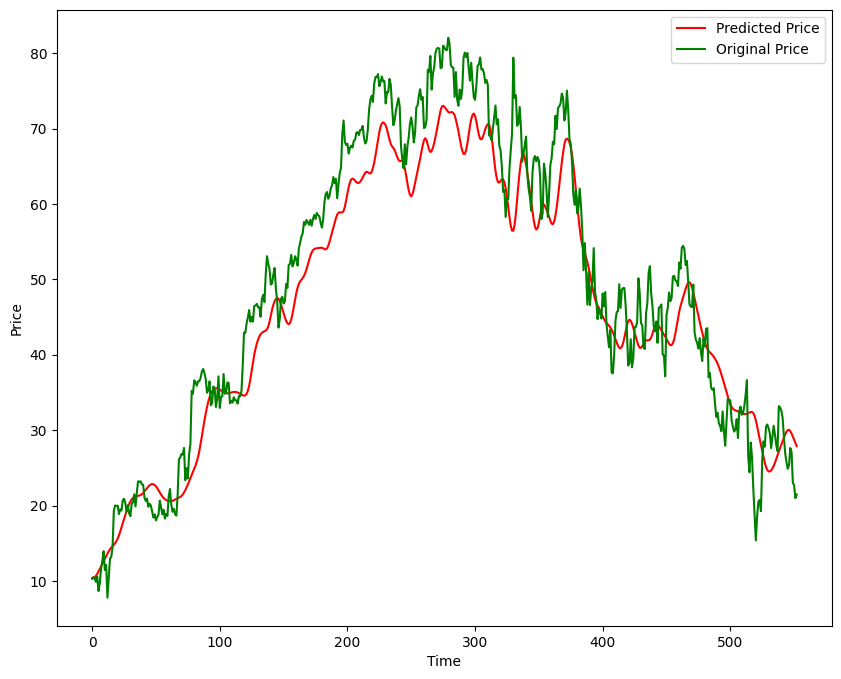

In [ ]:
plt.figure(figsize=(10,8))
plt.plot(y_predict, 'r', label = 'Predicted Price')
plt.plot(y, 'g', label = 'Original Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

In [ ]:
model.save('Stock Predictions Model.keras')